# Tutorial 2: Evaluating LLMs on MMLU

Sources:
https://arxiv.org/pdf/2411.00640

Welcome to the second tutorial in our AI Safety Evaluations course.

Benchmark evaluation is a core skill in applied ML, but the statistical side is often
treated as an afterthought — a single accuracy number gets reported, and model differences
are treated as real without checking whether they could arise from chance alone.
In this tutorial you will get hands-on experience running evaluations with the inspect_ai
library and applying basic statistical methods to interpret the results rigorously.

**What you'll learn:**

- Load and prepare a benchmark dataset
- Compute confidence intervals for accuracy
- Compare models statistically
- Perform power analysis to plan evaluation size

**By the end:** **You'll have a statistically rigorous evaluation pipeline that can tell you not just how accurate a model is, but whether observed differences between models are real.**

## 1. Setup

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from scipy import stats
from string import ascii_uppercase
from typing import Tuple, List

from inspect_ai import Task, task, eval
from inspect_ai.dataset import Sample, hf_dataset, FieldSpec
from inspect_ai.solver import multiple_choice
from inspect_ai.scorer import choice
from inspect_ai.log import EvalLog

In [2]:
# Imports to connect to Groq
import os
from urllib import response
import requests
from dotenv import load_dotenv
from litellm import completion

load_dotenv()

groq_key = os.environ.get("GROQ_API_KEY")
if not groq_key:
    print(
        "GROQ_API_KEY not found in environment variables. Please set it to connect to Groq."
    )


def check_groq():
    response = completion(
        model="groq/llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": "hello from litellm"}],
    )

    # Just output the text response to verify connection
    print("Response from Groq:")
    print(response.choices[0].message.content)


def check_quotio():
    """Check quotio connection and show available models."""
    base_url = "http://127.0.0.1:8317/v1"
    api_key = os.environ.get("QUOTIO_API_KEY", "")
    try:
        response = requests.get(
            f"{base_url}/models",
            headers={"Authorization": f"Bearer {api_key}"},
            timeout=5,
        )
        response.raise_for_status()
        models = response.json().get("data", [])

        print("Connected to quotio")
        print(f"Available models: {len(models)}")
        for model in models:
            print(f"  - {model['id']}")
    except requests.exceptions.ConnectionError:
        print("Cannot connect to quotio")
        print("Expected endpoint: http://127.0.0.1:8317/v1")


check_quotio()

check_groq()

Connected to quotio
Available models: 17
  - gpt-5.1-codex
  - gpt-5.1-codex-mini
  - gpt-5.1-codex-max
  - gpt-5.3-codex-spark
  - gpt-5.4
  - claude-sonnet-4.6
  - gpt-5.1
  - gpt-5.2-codex
  - gpt-5.3-codex
  - gpt-5.4-mini
  - claude-opus-4.6
  - claude-opus-4-6
  - claude-sonnet-4-6
  - gpt-5-codex
  - gpt-5-codex-mini
  - gpt-5.2
  - gpt-5
Response from Groq:
Hello from the other side. How are you doing today, littlem? Is there something I can help you with or would you like to chat?


In [3]:
# Configure models -- replace with what is available in your environment.
# Examples: 'ollama/llama3.2', 'openai/gpt-4o-mini', 'anthropic/claude-haiku-4-5'

# MODEL_A = "groq/llama-3.3-70b-versatile"  # weaker / baseline model
# MODEL_B = "groq/openai/gpt-oss-120b"  # stronger / comparison model

MODEL_A = "openai-api/nvidia/qwen/qwen2.5-7b-instruct"  # weaker / baseline model
MODEL_B = (
    "openai-api/nvidia/qwen/qwen3-next-80b-a3b-instruct"  # stronger / comparison model
)

## 2. Loading MMLU

`hf_dataset` is inspect_ai's loader for Hugging Face datasets. It downloads the data
and wraps each record in a `Sample` -- the standard container that flows through every
inspect_ai pipeline. A `Sample` carries the model input, the expected target, optional
answer choices, and arbitrary metadata you want to keep around.

MMLU stores the correct answer as an integer (0 = A, 1 = B, 2 = C, 3 = D).
The quickest way to load a dataset is with `FieldSpec`, which maps column names to
`Sample` fields. Let's try it first and see what we get.

In [4]:
dataset_raw = hf_dataset(
    path="cais/mmlu",
    name="all",
    split="test",
    sample_fields=FieldSpec(
        input="question",
        target="answer",  # raw MMLU answer is an integer index 0-3
        metadata=["choices", "subject"],
    ),
    cached=True,
)

sample = dataset_raw[0]
print("input   :", sample.input[:80], "...")
print("target  :", sample.target, "  <- integer index, not a letter!")
print("choices :", sample.metadata.get("choices"))

input   : Find the degree for the given field extension Q(sqrt(2), sqrt(3), sqrt(18)) over ...
target  : 1   <- integer index, not a letter!
choices : ['0', '4', '2', '6']


The `target` came out as an integer -- but inspect_ai's `multiple_choice()` solver
and `choice()` scorer expect it to be a letter (`"A"`, `"B"`, `"C"`, or `"D"`).
When the automatic mapping isn't enough, inspect_ai lets you pass a
**record-to-sample function** that receives the full raw record and returns a `Sample`
you construct yourself.

In [5]:
def record_to_sample(record: dict) -> Sample:
    """
    Convert a raw MMLU record to an inspect_ai Sample.
    
    MMLU stores the correct answer as an integer index (0=A, 1=B, 2=C, 3=D).
    We convert it to the corresponding uppercase letter so it matches the
    format expected by the choice() scorer.
    """
    answer_idx = int(record["answer"])
    return Sample(
        input=record["question"],
        choices=record["choices"],
        target=ascii_uppercase[answer_idx],  # 0->'A', 1->'B', ...
        metadata=dict(subject=record.get("subject")),
    )


dataset = hf_dataset(
    path="cais/mmlu",
    name="all",
    split="test",
    sample_fields=record_to_sample,
    cached=True,
    auto_id=True,
)

sample = dataset[0]
print("target  :", sample.target, " <- letter now")
print("choices :", sample.choices)

target  : B  <- letter now
choices : ['0', '4', '2', '6']


## Assignment 1: Create your working subset

All experiments in this notebook will run on a subject subset small enough to evaluate
quickly. `Dataset.filter()` takes a predicate over `Sample` objects; the `metadata`
field gives access to anything set in `record_to_sample` -- here, the MMLU subject tag.

We define `astronomy_subset` as a reference example. Pick any subject or subjects from the [MMLU subject list](https://huggingface.co/datasets/cais/mmlu#task-descriptions) with at least 50 questions so later analyses are statistically meaningful. Create MY_SUBSET and use it in all subsequent exercises.

In [6]:
# Get all subsets
subjects = set(sample.metadata.get("subject") for sample in dataset)
# Pretty printed list of subjects, with indentation and sorted alphabetically
print(f"Subjects in MMLU: {sorted(subjects)}")

Subjects in MMLU: ['abstract_algebra', 'anatomy', 'astronomy', 'business_ethics', 'clinical_knowledge', 'college_biology', 'college_chemistry', 'college_computer_science', 'college_mathematics', 'college_medicine', 'college_physics', 'computer_security', 'conceptual_physics', 'econometrics', 'electrical_engineering', 'elementary_mathematics', 'formal_logic', 'global_facts', 'high_school_biology', 'high_school_chemistry', 'high_school_computer_science', 'high_school_european_history', 'high_school_geography', 'high_school_government_and_politics', 'high_school_macroeconomics', 'high_school_mathematics', 'high_school_microeconomics', 'high_school_physics', 'high_school_psychology', 'high_school_statistics', 'high_school_us_history', 'high_school_world_history', 'human_aging', 'human_sexuality', 'international_law', 'jurisprudence', 'logical_fallacies', 'machine_learning', 'management', 'marketing', 'medical_genetics', 'miscellaneous', 'moral_disputes', 'moral_scenarios', 'nutrition', 'ph

In [7]:
# Reference subset used in worked examples
astronomy_subset = dataset.filter(lambda s: s.metadata.get("subject") == "astronomy")
print(f"Astronomy: {len(astronomy_subset)} questions")

formal_logic_subset = dataset.filter(
    lambda s: s.metadata.get("subject") == "formal_logic"
)
print(f"Formal Logic: {len(formal_logic_subset)} questions")

human_sexuality_subset = dataset.filter(
    lambda s: s.metadata.get("subject") == "human_sexuality"
)
print(f"Human Sexuality: {len(human_sexuality_subset)} questions")

logical_fallacies_subset = dataset.filter(
    lambda s: s.metadata.get("subject") == "logical_fallacies"
)
print(f"Logical Fallacies: {len(logical_fallacies_subset)} questions")

MY_SUBSET_1 = logical_fallacies_subset
MY_SUBSET_2 = human_sexuality_subset
MY_SUBSET = MY_SUBSET_1

print(f"My subset: {len(MY_SUBSET)} questions")

Astronomy: 152 questions
Formal Logic: 126 questions
Human Sexuality: 131 questions
Logical Fallacies: 163 questions
My subset: 163 questions


## 3. Running an evaluation

Every inspect_ai evaluation is described by a `Task`, which bundles three things:

- **dataset** -- the questions
- **solver** -- the chain of steps that produces a model response;
  `multiple_choice()` formats the prompt with lettered options and parses the model's choice
- **scorer** -- the function that grades the response;
  `choice()` checks whether the selected letter matches the target

The `@task` decorator registers the function so inspect_ai can discover it by name
from the CLI or pass it directly to `eval()`.

In [8]:
@task
def mmlu_subset(subset):
    """Minimal MMLU task for any subject subset."""
    return Task(dataset=subset, solver=[multiple_choice()], scorer=choice())

Calling `eval()` runs the task and returns a **list of `EvalLog` objects** -- one per
(task, model) pair. Everything you need is in this object; there is no need to read
log files from disk.

The two most useful attributes:
- `log.results.scores` -- list of scorer results, each with a `metrics` dict
  (`"accuracy"`, `"stderr"`, etc.)
- `log.samples` -- list of `EvalSample` objects with per-question inputs, outputs, and scores

In [11]:
# Rate-limited evaluation

logs: List[EvalLog] = eval(
    mmlu_subset(MY_SUBSET),
    model=MODEL_A,
    limit=10,  # evaluate only the first 10 questions
)

log = logs[0]  # one task -> one log
print("Status  :", log.status)
print("Model   :", log.eval.model)
print("Accuracy:", log.results.scores[0].metrics["accuracy"].value)

Output()

Status  : success
Model   : openai-api/nvidia/qwen/qwen2.5-7b-instruct
Accuracy: 1.0


## 4. From `EvalLog` to a DataFrame

## Assignment 2: Implement `log_to_df`

The aggregate accuracy in `log.results` is useful for a quick check, but for the
statistical analyses ahead we need a flat table: **one row per (question, epoch)**
with a numeric `score` column.

`log.samples` is a list of `EvalSample` objects. Each one has:
- `.id` -- question identifier
- `.epoch` -- which run this belongs to (relevant when `epochs > 1`)
- `.scores` -- a dict mapping scorer name to `Score`; the `Score.value` for `choice()` is
  `"C"` (correct) or `"I"` (incorrect)
- `.metadata` -- the metadata dict you set in `record_to_sample`

Implement `log_to_df` so that it converts an `EvalLog` into a DataFrame with columns
`id`, `epoch`, `score` (1/0), and `subject`. The smoke test below will verify the shape.

In [12]:
def log_to_df(log: EvalLog) -> pd.DataFrame:
    """
    Convert an EvalLog to a DataFrame with one row per (question, epoch).

    Columns:
        id      – question identifier
        epoch   – epoch index (0 if epochs=1)
        score   – 1 if correct, 0 otherwise
        subject – MMLU subject tag from metadata

    The choice() scorer stores the result as "C" (correct) or "I" (incorrect).
    """
    # Convert an EvalLog to a DataFrame with one row per (question, epoch).
    rows = []
    for sample in log.samples:
        score = 1 if sample.scores["choice"].value == "C" else 0
        rows.append(
            {
                "id": sample.id,
                "epoch": sample.epoch,
                "score": score,
                "subject": sample.metadata["subject"],
            }
        )
    df = pd.DataFrame(rows)
    return df

    raise NotImplementedError


# =================================== TESTS ===================================
df_test = log_to_df(log)

assert set(df_test.columns) >= {"id", "epoch", "score", "subject"}
assert df_test["score"].isin([0, 1]).all()
# assert len(df_test) == 10

print(df_test.head())
print(f"\nAccuracy: {df_test['score'].mean():.1%}")


     id  epoch  score            subject
0  6673      1      1  logical_fallacies
1  6674      1      1  logical_fallacies
2  6675      1      1  logical_fallacies
3  6676      1      1  logical_fallacies
4  6677      1      1  logical_fallacies

Accuracy: 100.0%


## 5. Confidence intervals


A single accuracy number carries uncertainty: the eval used a finite set of questions
sampled from a much larger space. The paper (ss2.1, ss3.1) shows how to quantify this
using the CLT standard error.


## Assignment 3: Implement `ci_accuracy_basic` and `ci_accuracy`

**`ci_accuracy_basic(scores, ci)`** -- the simple case where every question is answered
exactly once. `scores` is a plain numpy array of 0s and 1s. Use Eq. 1 from the paper.

**`ci_accuracy(df, ci)`** -- the general case that handles multiple runs per question
(`epochs > 1`). When K runs exist for a question, average their scores first, then
compute the SE across question-level averages. Pooling all K×n individual answers
would undercount variance -- answers to the same question across epochs are correlated.


In [ ]:
def ci_accuracy_basic(
    scores: np.ndarray, ci: float = 0.95
) -> Tuple[float, float, float]:
    """
    CLT-based confidence interval for accuracy -- single run per question (K = 1).

    Parameters
    ----------
    scores : 1-D array of per-question binary scores (0 or 1)
    ci     : confidence level (default 0.95)

    Returns
    -------
    (lower_bound, mean_accuracy, upper_bound)
    """
    scores = np.asarray(scores, dtype=float)
    n = len(scores)
    mean_acc = np.mean(scores)
    se = np.sqrt(mean_acc * (1 - mean_acc) / n)
    z = stats.norm.ppf(0.5 + ci / 2)
    lower_bound = mean_acc - z * se
    upper_bound = mean_acc + z * se
    return lower_bound, mean_acc, upper_bound


def ci_accuracy(df: pd.DataFrame, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    CLT-based confidence interval for accuracy, supporting multiple epochs (K >= 1).

    Parameters
    ----------
    df : DataFrame returned by log_to_df, with columns 'id', 'score', 'epoch'
    ci : confidence level (default 0.95)

    Returns
    -------
    (lower_bound, mean_accuracy, upper_bound)
    """

    # Aggregate scores by question ID, averaging over epochs
    question_means = df.groupby("id")["score"].mean().to_numpy(dtype=float)

    # Now question_means is a 1-D array of mean scores per question
    n = len(question_means)
    mean_acc = question_means.mean()
    se = question_means.std(ddof=0) / np.sqrt(n)
    z = stats.norm.ppf(0.5 + ci / 2)
    lower_bound = mean_acc - z * se
    upper_bound = mean_acc + z * se
    return lower_bound, mean_acc, upper_bound

In [ ]:
# =================================== TESTS ===================================
def _make_df(ids, scores, epochs=None):
    if epochs is None:
        epochs = [0] * len(ids)
    return pd.DataFrame({"id": ids, "score": scores, "epoch": epochs})


# ci_accuracy_basic
l, m, u = ci_accuracy_basic(np.ones(10))

assert l == 1.0 and u == 1.0, "perfect accuracy: CI should collapse to 1"

l, m, u = ci_accuracy_basic(np.zeros(10))

assert l == 0.0 and u == 0.0, "zero accuracy: CI should collapse to 0"

scores3 = np.array([1, 1, 0, 1, 0], dtype=float)
l, m, u = ci_accuracy_basic(scores3)

assert l < 0.6 < u, f"0.6 not in [{l:.3f}, {u:.3f}]"

np.random.seed(42)
s = np.random.binomial(1, 0.75, 200).astype(float)
l95, _, u95 = ci_accuracy_basic(s, 0.95)
l99, _, u99 = ci_accuracy_basic(s, 0.99)

assert (u99 - l99) > (u95 - l95), "99% CI must be wider than 95%"
assert np.isclose(l95, 0.6819421067148456, atol=10e-2)
assert np.isclose(u95, 0.8080578932851544, atol=10e-2)

# ci_accuracy (K=1 should match basic)
df3 = _make_df([1, 2, 3, 4, 5], scores3.tolist())
l_df, _, u_df = ci_accuracy(df3)
l_ar, _, u_ar = ci_accuracy_basic(scores3)

assert np.isclose(l_df, l_ar) and np.isclose(u_df, u_ar), "K=1 must match basic version"

# ci_accuracy (K=3 should give narrower CI on average)
np.random.seed(0)
rows_k1, rows_k3 = [], []
for q in range(30):
    p = np.random.uniform(0.3, 0.9)
    rows_k1.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": 0})
    for e in range(3):
        rows_k3.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": e})

l1, _, u1 = ci_accuracy(pd.DataFrame(rows_k1))
l3, _, u3 = ci_accuracy(pd.DataFrame(rows_k3))
print(f"K=1 width: {u1 - l1:.3f}")
print(f"K=3 width: {u3 - l3:.3f}  (narrower on average)")
print("\n✓ All tests passed!")

K=1 width: 0.337
K=3 width: 0.223  (narrower on average)

✓ All tests passed!


## 6. Visualising how CIs shrink

Two things make confidence intervals narrower: more questions (larger n) and more
runs per question (larger K). Your task is to visualise those effects.

## Assignment 4.1: Plot CI width vs number of epochs


Output()

Running 1 runs per question ...


Running 2 runs per question ...


Output()

Running 3 runs per question ...


Output()

Output()

Running 5 runs per question ...


Running 8 runs per question ...


Output()

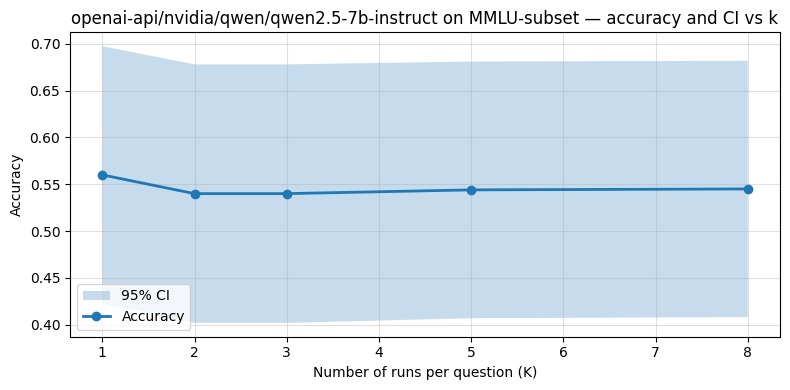

   K  accuracy  ci_lower  ci_upper  ci_width
0  1     0.560    0.4224    0.6976    0.2752
1  2     0.540    0.4019    0.6781    0.2763
2  3     0.540    0.4019    0.6781    0.2763
3  5     0.544    0.4068    0.6812    0.2743
4  8     0.545    0.4080    0.6820    0.2740


In [ ]:
k_values = [1, 2, 3, 5, 8]
accuracies = []
ci_lowers = []
ci_uppers = []
n_questions = 50

# Running n_questions for more runs per question (K). Using eval() with a subset of MMLU
for k in k_values:
    print(f"Running {k} runs per question ...")
    run_logs = eval(
        mmlu_subset(dataset),
        model=MODEL_A,
        epochs=k,
        log_level="debug",
        limit=n_questions,
        # max_connections=4,
        max_retries=2,
        # cache=False,
    )
    df = log_to_df(run_logs[0])
    l, acc, u = ci_accuracy(df)
    accuracies.append(acc)
    ci_lowers.append(l)
    ci_uppers.append(u)

plt.figure(figsize=(8, 4))
plt.fill_between(k_values, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(k_values, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of runs per question (K)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs k")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

ci_widths = [u - l for l, u in zip(ci_lowers, ci_uppers)]

width_table = pd.DataFrame(
    {
        "K": k_values,
        "accuracy": accuracies,
        "ci_lower": ci_lowers,
        "ci_upper": ci_uppers,
        "ci_width": ci_widths,
    }
)

print(width_table.round(4))

---
1. Look at how fast the band narrows.
   At what point does running another epoch stop being worth it?
2. Does more K change your estimate of the model's accuracy, or just your confidence in it?
3. What does this tell you about how to allocate your evaluation budget?

**Your answer:**
1. Didn't narrow at all :(
2. Should influence both? 
3. There's always a sweet spot - maybe we should stop when our confidence/p-value desideratas are achieved?

## Assignment 4.2: Compute and plot CI width vs n

For each sample size n in `range(10, len(question_ids)+1, 10)`, slice both DataFrames
to the first n question IDs, compute `ci_accuracy`, and record the CI width.
Then plot width vs n.

In [ ]:
question_ids = MY_SUBSET.filter(lambda s: s.id in question_ids)

Output()

Dataset sizes: range(10, 100, 10)
Running 10 questions...


Output()

Running 20 questions...


Output()

...

Running 80 questions...


Output()

Output()

Running 90 questions...


    n  accuracy  ci_lower  ci_upper  ci_width
0  10    0.3000    0.0160    0.5840    0.5681
1  20    0.5000    0.2809    0.7191    0.4383
2  30    0.5000    0.3211    0.6789    0.3578
3  40    0.5250    0.3702    0.6798    0.3095
4  50    0.5400    0.4019    0.6781    0.2763
5  60    0.4833    0.3569    0.6098    0.2529
6  70    0.4857    0.3686    0.6028    0.2342
7  80    0.4750    0.3656    0.5844    0.2189
8  90    0.5222    0.4190    0.6254    0.2064


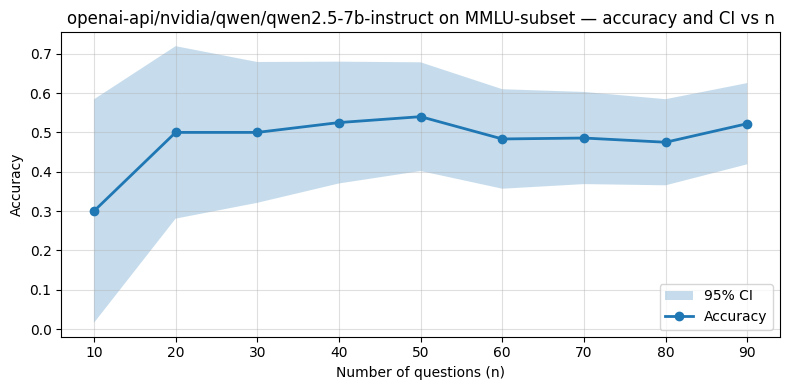

In [ ]:
# Selecting a subset of questions from full MY_SUBSET, as an eval task
# question_ids =
dataset_sizes = range(10, 100, 10)
print(f"Dataset sizes: {dataset_sizes}")
accuracies = []
ci_lowers = []
ci_uppers = []

for n in dataset_sizes:
    print(f"Running {n} questions...")
    run_logs = eval(
        mmlu_subset(dataset),
        model=MODEL_A,
        epochs=1,
        log_level="debug",
        limit=n,
        max_connections=4,
        max_retries=2,
        # cache=False,
    )
    df = log_to_df(run_logs[0])
    l, acc, u = ci_accuracy(df)
    accuracies.append(acc)
    ci_lowers.append(l)
    ci_uppers.append(u)

ci_widths = [u - l for l, u in zip(ci_lowers, ci_uppers)]

width_table = pd.DataFrame(
    {
        "n": dataset_sizes,
        "accuracy": accuracies,
        "ci_lower": ci_lowers,
        "ci_upper": ci_uppers,
        "ci_width": ci_widths,
    }
)

print(width_table.round(4))

plt.figure(figsize=(8, 4))
plt.fill_between(dataset_sizes, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(dataset_sizes, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of questions (n)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs n")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
1. At what n does the accuracy line start to feel stable?
2. Compare that number to the size of `MY_SUBSET` — are you in the reliable region?
3. Compare this curve to the one in 4.1. What is the difference in what K and n actually buy you?

**Your answer:**
1. I'd say ~30, around that.
2. It's approximately 1/5 of MY_SUBSET
3. Converging to a closer "stable truth" point; somewhat a budget-accuracy tradeoff

## 7. Comparing two models

Reporting two accuracy numbers side by side doesn't tell you whether the gap is real
or just noise. The paper (§4.2) describes a **paired test**: because both models answer
the same questions, you can compute per-question score differences and test whether
their mean differs significantly from zero. This removes question-difficulty variance
and yields a lower standard error than treating the two runs as independent samples.


## Assignment 5: Compare two models

`run_and_get_scores` and `compare_models_paired` are provided. Complete
`significance_by_paired_ttest` and use it to compare the two models on `MY_SUBSET`.

Implement `significance_by_paired_ttest` and compare MODEL_A and MODEL_B.

In [58]:
def run_and_get_scores(model_name: str, dataset, epochs: int = 1, cot=False) -> np.ndarray:
    """Run eval and return mean-per-question scores, sorted by question id."""
    print(f"  Running {model_name} ...")
    run_logs = eval(
        mmlu_subset(dataset), 
        model=model_name, 
        epochs=epochs,
        log_level="info",
        cot=cot)
    df = log_to_df(run_logs[0])
    return df.groupby("id")["score"].mean().sort_index().values


def significance_by_paired_ttest(
    scores1: np.ndarray,
    scores2: np.ndarray,
    alpha: float = 0.05,
    two_tailed: bool = True,
) -> Tuple[float, float, bool]:
    """
    Paired t-test between two sets of per-question scores.

    Returns (p_value, mean_difference scores1 - scores2, is_significant).
    """
    assert len(scores1) == len(scores2), "arrays must cover the same questions"

    alternative = "two-sided" if two_tailed else "greater"

    _, p_value = stats.ttest_rel(scores1, scores2, alternative=alternative)
    mean_diff = np.mean(scores1) - np.mean(scores2)

    return p_value, mean_diff, bool(p_value < alpha)


def compare_models_paired(
    model_a: str,
    model_b: str,
    dataset,
    alpha: float = 0.05,
    two_tailed: bool = True,
    epochs_a: int = 1,
    epochs_b: int = 1,
) -> Tuple[float, float, bool]:
    """
    Evaluate both models on the same dataset and run a paired t-test.

    Returns (p_value, mean_difference A - B, is_significant).
    """
    scores_a = run_and_get_scores(model_a, dataset, epochs=epochs_a)
    scores_b = run_and_get_scores(model_b, dataset, epochs=epochs_b)
    return significance_by_paired_ttest(scores_a, scores_b, alpha, two_tailed)



# p, d, sig  = compare_models_paired(MODEL_A, MODEL_B, MY_SUBSET, alpha=0.05)

In [ ]:
# Run and save eval results
scores_a = run_and_get_scores(MODEL_A, MY_SUBSET, epochs=1)
scores_b = run_and_get_scores(MODEL_B, MY_SUBSET, epochs=1)

Output()

  Running openai-api/nvidia/qwen/qwen2.5-7b-instruct ...


Output()

  Running openai-api/nvidia/qwen/qwen3-next-80b-a3b-instruct ...


In [49]:
from inspect_ai.log import list_eval_logs, read_eval_log

logs = list_eval_logs()
scores_b = read_eval_log(logs[0])
scores_a = read_eval_log(logs[1])

In [50]:
df_a = log_to_df(scores_a)
df_b = log_to_df(scores_b)
sc_a = df_a.groupby("id")["score"].mean().sort_index().values
sc_b = df_b.groupby("id")["score"].mean().sort_index().values


In [33]:
# =================================== TESTS ===================================
p, d, sig = significance_by_paired_ttest(np.array([1, 2, 3]), np.array([1, 2, 3]))

assert np.isclose(d, 0.0) and not sig

p, d, sig = significance_by_paired_ttest(
    np.array([1, 1, 1, 1, 1]), np.array([0, 0, 0, 0, 0]), two_tailed=False
)

assert sig and d > 0

print("All tests passed!")

All tests passed!


/Users/zakhar/Documents/code/monoid/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)


In [34]:
p, mean, sig = significance_by_paired_ttest(sc_a, sc_b)
print(f"p = {p:.3f}, mean = {mean:.3f}, sig = {sig}")

p = 0.004, mean = -0.080, sig = True


### 1. Write down the p-value and the mean difference you got.
p-value ~= 0.004 
mean difference ~= -0.080
### 2. Is the gap significant? Is it large enough to matter in practice?
Definitely. For higher results, this could mean winning a competition/conference benchmark.
### 3. What would change your conclusion: more questions, a different subject, or a different model pair?
I've tried a LOT of model pairs, so definitely changing the model pair would change things. I'd reckon a different subject would, too. More questions - likely better 'accuracy', as we've established before.

## 8. Interval estimation of the accuracy difference

In Assignment 5 you got a yes/no significance decision. Here you will estimate the size of the gap and its uncertainty: a confidence interval on the difference gives both pieces of information at once.

## Assignment 6: Estimate the accuracy gap

Implement `ci_accuracy_for_difference` to compute a 95% CI on the per-question score differences.

Compute and report the confidence interval on MODEL_A − MODEL_B.


In [35]:
# Compute a 95% CI for per-question score differences
def ci_accuracy_for_difference(
    scores1: np.ndarray,
    scores2: np.ndarray,
    alpha: float = 0.05,
) -> Tuple[float, float, float]:
    diffs = np.asarray(scores1, dtype=float) - np.asarray(scores2, dtype=float)
    n = len(diffs)
    mean_diff = diffs.mean()
    se = diffs.std(ddof=1) / np.sqrt(n)
    z = stats.norm.ppf(1 - alpha / 2)
    lower = mean_diff - z * se
    upper = mean_diff + z * se
    return lower, mean_diff, upper


def compare_models_paired_ci(
    model_a: str,
    model_b: str,
    dataset,
    alpha: float = 0.05,
    epochs_a: int = 1,
    epochs_b: int = 1,
) -> Tuple[np.ndarray, np.ndarray, Tuple[float, float, float]]:
    scores_a = run_and_get_scores(model_a, dataset, epochs=epochs_a)
    scores_b = run_and_get_scores(model_b, dataset, epochs=epochs_b)
    return scores_a, scores_b, ci_accuracy_for_difference(scores_a, scores_b, alpha)

# scoresa, scoresb, ci = compare_models_paired_ci(MODEL_A, MODEL_B, MY_SUBSET, alpha=0.05)

ci_acc_diff_a, ci_acc_diff_b, ci = ci_accuracy_for_difference(sc_a, sc_b)

In [41]:
# Pretty print on each line, rounded to 3 decimal places
print(f"95% CI for A - B: {round(ci,3)}") 
print(f"95% CI for A: {round(ci_acc_diff_a,3)}")
print(f"95% CI for B: {round(ci_acc_diff_b,3)}")

95% CI for A - B: -0.026
95% CI for A: -0.134
95% CI for B: -0.08


---
1. Write down the interval. Does it contain zero?
2. How does this relate to the significance test in Assignment 5 — do they tell the same story?
3. Which result is more informative — the p-value or the interval? Why?

**Your answer:**
1. The interval is [-0.134, -0.08], not containing zero.
2. Telling the same story - model B is just better.
3. Interval is more informative as p-value is just the probability this is significant. Interval also shows the approximate effect size so that we can estimate how big the advantage/difference is.

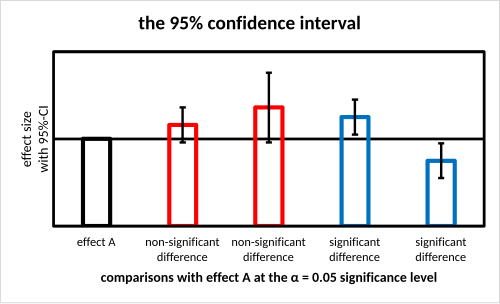

## 9. Power analysis

Before running an expensive evaluation, it is worth asking: how many questions do we
need to detect a meaningful difference with adequate statistical power?
The paper (§5) derives the minimum detectable effect as a function of sample size n,
question-level variance ω², and within-model variance σ².

## Assignment 7: 'Estimate variance components'

Implement `estimate_variance_components` and report the MDE for `MY_SUBSET` at α = 0.05, power = 80%.

In [46]:
def estimate_variance_components(
    logs_a: List[EvalLog],
    logs_b: List[EvalLog],
) -> dict:
    """
    Estimate omega2, sigma2_a, sigma2_b from two EvalLog objects (see ss5 of the paper).

    Both logs must cover the same set of questions. Use epochs >= 2 so that
    within-question variance can be estimated.

    Returns dict with keys 'omega2', 'sigma2_a', 'sigma2_b'.
    """

    assert len(logs_a) == len(logs_b), "logs must cover the same set of questions"
    
    def _coerce_log(logs) -> EvalLog:
        if isinstance(logs, list):
            assert len(logs) == 1, "expected exactly one EvalLog per eval() call"
            return logs[0]
        return logs
    
    df_a = log_to_df(_coerce_log(logs_a))
    df_b = log_to_df(_coerce_log(logs_b))

    mean_a = df_a.groupby("id")["score"].mean().sort_index()
    mean_b = df_b.groupby("id")["score"].mean().sort_index()

    common_ids = mean_a.index.intersection(mean_b.index)
    mean_a = mean_a.loc[common_ids].to_numpy(dtype=float)
    mean_b = mean_b.loc[common_ids].to_numpy(dtype=float)

    omega2 = np.var(mean_a - mean_b, ddof=1)

    sigma2_a = (
        df_a.groupby("id")["score"].var(ddof=1).fillna(0).loc[common_ids].mean()
    )
    sigma2_b = (
        df_b.groupby("id")["score"].var(ddof=1).fillna(0).loc[common_ids].mean()
    )

    return {
        "omega2": float(omega2),
        "sigma2_a": float(sigma2_a),
        "sigma2_b": float(sigma2_b),
    }


def minimum_detectable_effect(
    n: int,
    omega2: float,
    sigma2_a: float = 0.0,
    sigma2_b: float = 0.0,
    ka: int = 1,
    kb: int = 1,
    alpha: float = 0.05,
    power: float = 0.80,
) -> float:
    """MDE for a paired model comparison (Eq. 10 in the paper)."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta = stats.norm.ppf(power)
    return float(
        (z_alpha + z_beta) * np.sqrt((omega2 + sigma2_a / ka + sigma2_b / kb) / n)
    )

In [54]:
print("Running pilot evals ...")
logs_a = eval(mmlu_subset(MY_SUBSET), model=MODEL_A, epochs=2, limit=15)
logs_b = eval(mmlu_subset(MY_SUBSET), model=MODEL_B, epochs=2, limit=15)

params = estimate_variance_components(logs_a, logs_b)
print(f"omega2  = {params['omega2']:.4f}")
print(f"sigma2_A = {params['sigma2_a']:.4f}")
print(f"sigma2_B = {params['sigma2_b']:.4f}")

mde = minimum_detectable_effect(n=len(MY_SUBSET), **params)
print(f"\nWith n={len(MY_SUBSET)} questions -> MDE = {mde:.1%}")
print("(smallest gap detectable at 80% power, alpha=0.05)")

Output()

Running pilot evals ...


Output()

omega2  = 0.2310
sigma2_A = 0.0000
sigma2_B = 0.0333

With n=163 questions -> MDE = 11.3%
(smallest gap detectable at 80% power, alpha=0.05)


---
1. What MDE did you get for `MY_SUBSET`? Is that gap practically meaningful?
2. If the MDE is larger than the gap you observed in Assignment 5,
   what does that say about your earlier result?

**Your answer:**
1. 11.3%. Probably that the earlier result (mean diff = 8%) should be treated with caution: we can't reliably say that benchmark had enough power to detect this gap.
2. The benchmark is underpowered to reliably detect a difference of this size. Maybe we could increase the number of questions? Still too small of a pilot to make a confident conclusion about the whole benchmark's power.

## Assignment 8: Implement `required_sample_size`

`minimum_detectable_effect` computes delta given n. Implement its inverse:
given a target delta, return the minimum n needed. Use the sample-size formula
from ss5 of the paper (Eq. 9). Verify it passes the round-trip check,
then use it to compute how many questions you would need to detect a 5% and a 10%
accuracy gap on `MY_SUBSET`.

In [56]:
# --- Assignment 7 -----------------------------------------------------------
import math


def required_sample_size(
    delta: float,
    omega2: float,
    sigma2_a: float = 0.0,
    sigma2_b: float = 0.0,
    ka: int = 1,
    kb: int = 1,
    alpha: float = 0.05,
    power: float = 0.80,
) -> int:
    """Minimum number of questions needed to detect `delta` at the given power."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta = stats.norm.ppf(power)

    n = ((z_alpha + z_beta) ** 2) * (
        omega2 + sigma2_a / ka + sigma2_b / kb
    ) / (delta ** 2)

    return math.ceil(n)

# =================================== TESTS ===================================
n_needed = required_sample_size(delta=0.05, **params)
print(f"Questions needed to detect delta=5%: {n_needed}")
n_needed_10 = required_sample_size(delta=0.10, **params)
print(f"Questions needed to detect delta=10%: {n_needed_10}")

mde_check = minimum_detectable_effect(n=n_needed, **params)

assert abs(mde_check - 0.05) < 0.005, f"Round-trip failed: MDE={mde_check:.3f}"

print("Round-trip check passed!")

Questions needed to detect delta=5%: 830
Questions needed to detect delta=10%: 208
Round-trip check passed!


In [ ]:
# YOUR CODE HERE

---
1. How many questions do you need to detect a 5% gap? A 10% gap?
2. Does `MY_SUBSET` have enough questions to be a useful benchmark for comparing these two models?

**Your answer:**
1. Questions needed to detect delta=5%: 830
Questions needed to detect delta=10%: 208

2. Nah, it only has 163...

## Assignment 9: Compare a model with itself: baseline vs chain-of-thought

The `multiple_choice()` solver we have used so far prompts the model to answer
directly. inspect_ai also provides a `chain_of_thought` that asks the model
to reason step by step before giving its final answer.

Using the paired comparison infrastructure from Section 7, evaluate the same model
twice on the same subset — once with the default solver and once with
`chain_of_thought` — and test whether the difference in accuracy is statistically
significant. Does reasoning help? Is the effect consistent across subjects?

In [68]:
# Keep two separate layers:
# 1. raw EvalLog objects -> needed for variance components
# 2. per-question mean score arrays -> needed for CI / paired comparisons

def run_eval_log(model_name: str, dataset, epochs: int = 1, cot: bool = False) -> EvalLog:
    """Run one eval and return the single EvalLog."""
    run_logs = eval(
        mmlu_subset(dataset),   # adapt this if your task builder uses a different CoT flag
        model=model_name,
        epochs=epochs,
        log_level="info",
        cot=cot
    )
    assert len(run_logs) == 1, "expected one EvalLog"
    return run_logs[0]


print("Running CoT vs non-CoT evals ...")

log_cot = run_eval_log(MODEL_A, MY_SUBSET, epochs=1, cot=True)
log_non_cot = run_eval_log(MODEL_A, MY_SUBSET, epochs=1, cot=False)

# Convert each raw log to a dataframe-like table of (question, epoch, score)
df_cot = log_to_df(log_cot)
df_non_cot = log_to_df(log_non_cot)

# Reduce to one mean score per question for paired comparison / CI
sc_cot = df_cot.groupby("id")["score"].mean().sort_index().values
sc_non_cot = df_non_cot.groupby("id")["score"].mean().sort_index().values

# ci_accuracy_for_difference returns: (lower, mean_diff, upper)
ci_lower, mean_diff, ci_upper = ci_accuracy_for_difference(
    sc_cot, sc_non_cot, alpha=0.05
)

print(f"95% CI for CoT - non-CoT: [{ci_lower:.3f}, {ci_upper:.3f}]")
print(f"Mean difference (CoT - non-CoT): {mean_diff:.3f}")

# Variance components must use the raw logs, not the reduced score arrays
params = estimate_variance_components([log_cot], [log_non_cot])
print(f"omega2   = {params['omega2']:.4f}")
print(f"sigma2_CoT = {params['sigma2_a']:.4f}")
print(f"sigma2_nonCoT = {params['sigma2_b']:.4f}")

mde = minimum_detectable_effect(n=len(MY_SUBSET), **params)
print(f"MDE with n={len(MY_SUBSET)}: {mde:.1%}")


Output()

Running CoT vs non-CoT evals ...


Output()

95% CI for CoT - non-CoT: [-0.006, 0.018]
Mean difference (CoT - non-CoT): 0.006
omega2   = 0.0061
sigma2_CoT = 0.0000
sigma2_nonCoT = 0.0000
MDE with n=163: 1.7%


---
1. Does chain-of-thought help? By how much, and is it significant?
Not helping, 0.6% + not significant (CI crosses 0)
2. Does the result surprise you? What might explain it?
Not surprised IMO - I was fairly sure:
- Qwen are already good
- They're benchmaxxed a bit
3. Would you expect the same pattern on a different subject?
I'd definitely expect different patterns on touchy/biased subjects e.g. politics, sexuality, hate, religion, etc. + on stuff that requires step-by-step reasoning, e.g. small math/physics problems

## Bonus assignment: Clustered Standard Errors

Some benchmarks contain groups of related questions — for example, several questions
about the same passage in reading comprehension tasks like DROP or RACE. In such cases
the standard CLT confidence interval is anti-conservative: questions within a group are
correlated, so the effective sample size is smaller than n. Miller (2024) addresses this
with clustered standard errors (§2.2).

Using a reading comprehension benchmark of your choice, implement the clustered
confidence interval (Eq. 4 from the paper) and compare it against the naive CLT interval.
How much wider is the clustered interval? Does the difference depend on the benchmark?
Then compare two models on the same benchmark using the clustered paired standard error
(Eq. 8) — does the conclusion about which model is better change compared to the
naive paired test?

In [ ]:
# YOUR CODE HERE